# Credit Card Fraud Detection Analysis

# Project : Credit Card Fraud Detection

**Objective:** Detect fraudulent credit card transactions based on transaction patterns and customer behavior.

## Dataset Summary

**Source file:** cleaned_creditcfraud.csv  
**Rows:** 10001  
**Columns:** 10

**Features**
- transaction_id (numeric - unique identifier)
- amount (numeric - transaction amount)
- transaction_hour (numeric - hour of transaction 0-23)
- merchant_category (categorical - type of merchant)
- foreign_transaction (binary - 0/1, whether transaction is international)
- location_mismatch (binary - 0/1, whether billing/shipping location mismatch)
- device_trust_score (numeric - device security score 0-100)
- velocity_last_24h (numeric - number of transactions in last 24 hours)
- cardholder_age (numeric - age of cardholder)

**Target**
- is_fraud (binary - 0/1, whether transaction is fraudulent)

## Feature Effects (Expected)

These are general, model-agnostic expectations about how each feature could influence `is_fraud`.

- **amount:** Higher transaction amounts may be more likely to be fraudulent, though legitimate high-value purchases also exist.
- **transaction_hour:** Unusual hours (late night/early morning) may indicate higher fraud risk.
- **merchant_category:** Certain merchant types may be more prone to fraud (e.g., online electronics vs. grocery stores).
- **foreign_transaction:** International transactions often have higher fraud rates due to distance and verification challenges.
- **location_mismatch:** Significant mismatch between billing and transaction location is a strong fraud indicator.
- **device_trust_score:** Lower trust scores indicate higher risk; compromised devices are commonly used in fraud.
- **velocity_last_24h:** High transaction frequency in a short period may indicate account takeover or card testing.
- **cardholder_age:** Younger or older cardholders may have different fraud patterns based on usage behavior.

Use model coefficients or feature importance later to validate these assumptions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## 1. Load and Display Data

In [3]:
df = pd.read_csv('cleaned_creditcfraud.csv')
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


## 2. Data Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [5]:
df.shape
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

## 3. Check for Missing Values

In [6]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

## 4. Statistical Summary

In [7]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


## 5. Fraud Distribution Analysis

Fraud Distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Fraud Rate: 0.0151


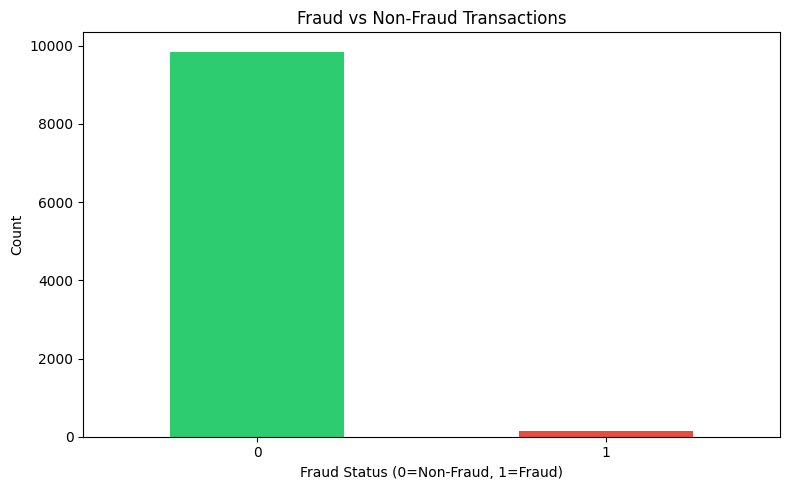

In [8]:
fraud_counts = df['is_fraud'].value_counts()
print("Fraud Distribution:")
print(fraud_counts)
print(f"\nFraud Rate: {df['is_fraud'].mean():.4f}")

plt.figure(figsize=(8, 5))
fraud_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Status (0=Non-Fraud, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Correlation with Fraud:
is_fraud               1.000000
foreign_transaction    0.185597
location_mismatch      0.173009
velocity_last_24h      0.103413
amount                 0.028404
cardholder_age        -0.000590
transaction_id        -0.010155
device_trust_score    -0.137913
transaction_hour      -0.138665
Name: is_fraud, dtype: float64


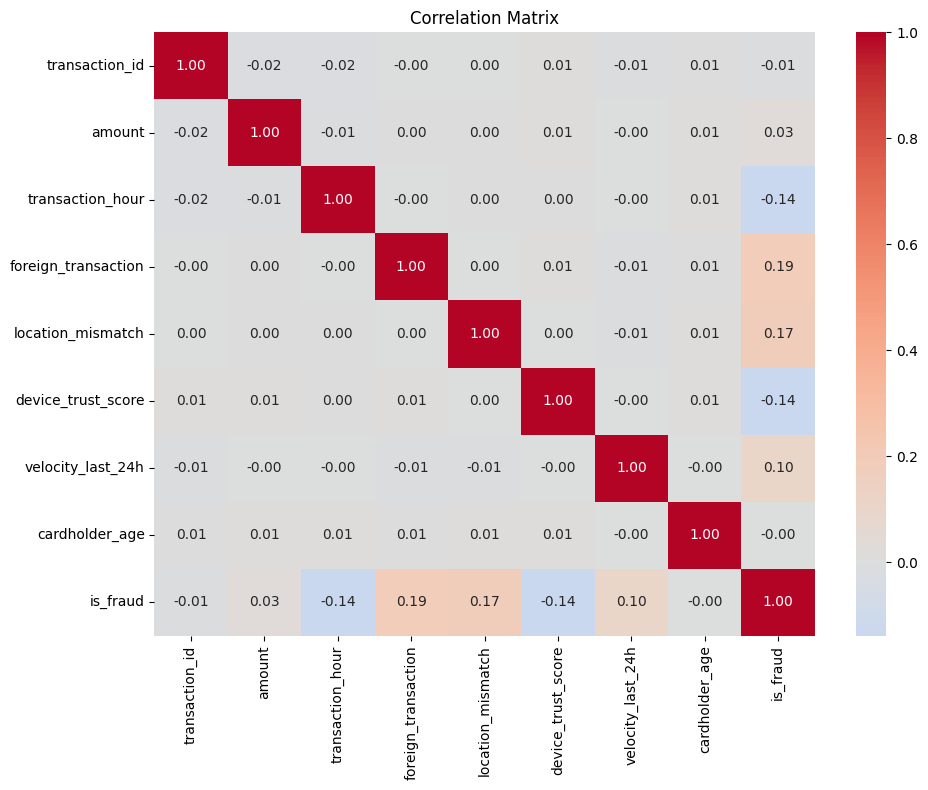

In [9]:
correlation_matrix = df.corr(numeric_only=True)
fraud_corr = correlation_matrix['is_fraud'].sort_values(ascending=False)
print("Correlation with Fraud:")
print(fraud_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Feature Analysis by Fraud Status

Average Feature Values by Fraud Status:
              amount  transaction_hour  device_trust_score  velocity_last_24h  \
is_fraud                                                                        
0         175.333015         11.712154           62.165804           1.990557   
1         216.182980          3.841060           37.867550           3.205298   

          cardholder_age  
is_fraud                  
0              43.469794  
1              43.397351  


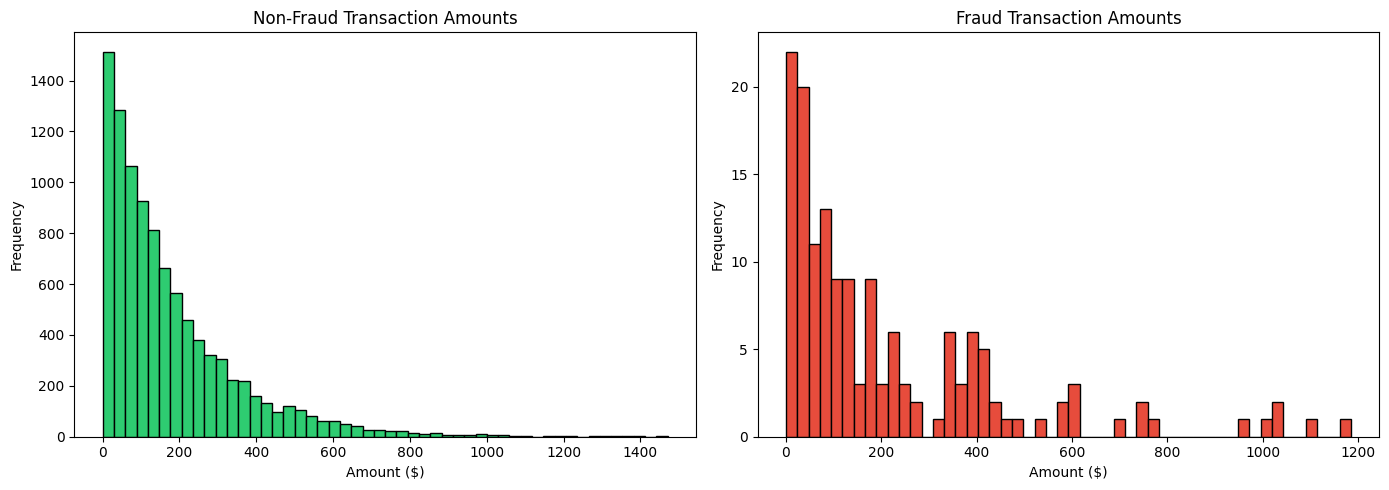

In [10]:
grouped_analysis = df.groupby('is_fraud')[['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']].mean()
print("Average Feature Values by Fraud Status:")
print(grouped_analysis)

# Visualize transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fraud_status in [0, 1]:
    data = df[df['is_fraud'] == fraud_status]['amount']
    label = 'Fraud' if fraud_status == 1 else 'Non-Fraud'
    axes[fraud_status].hist(data, bins=50, edgecolor='black', color=['#2ecc71', '#e74c3c'][fraud_status])
    axes[fraud_status].set_title(f'{label} Transaction Amounts')
    axes[fraud_status].set_xlabel('Amount ($)')
    axes[fraud_status].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 8. Data Preparation for Modeling

In [12]:
# Encode categorical variables
le = LabelEncoder()
df_encoded = df.copy()
df_encoded['merchant_category'] = le.fit_transform(df['merchant_category'])

# Separate features and target
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

Features shape: (10000, 9)
Target shape: (10000,)

Features used:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


## 9. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training fraud rate: {y_train.mean():.4f}")
print(f"Test fraud rate: {y_test.mean():.4f}")

Training set size: 8000
Test set size: 2000
Training fraud rate: 0.0151
Test fraud rate: 0.0150


## 10. Model Building - Random Forest Classifier

In [14]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Model trained successfully!")
print(f"Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {rf_model.score(X_test, y_test):.4f}")

Model trained successfully!
Training accuracy: 1.0000
Test accuracy: 0.9980


## 11. Model Evaluation

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00      1970
       Fraud       1.00      0.87      0.93        30

    accuracy                           1.00      2000
   macro avg       1.00      0.93      0.96      2000
weighted avg       1.00      1.00      1.00      2000


ROC-AUC Score: 1.0


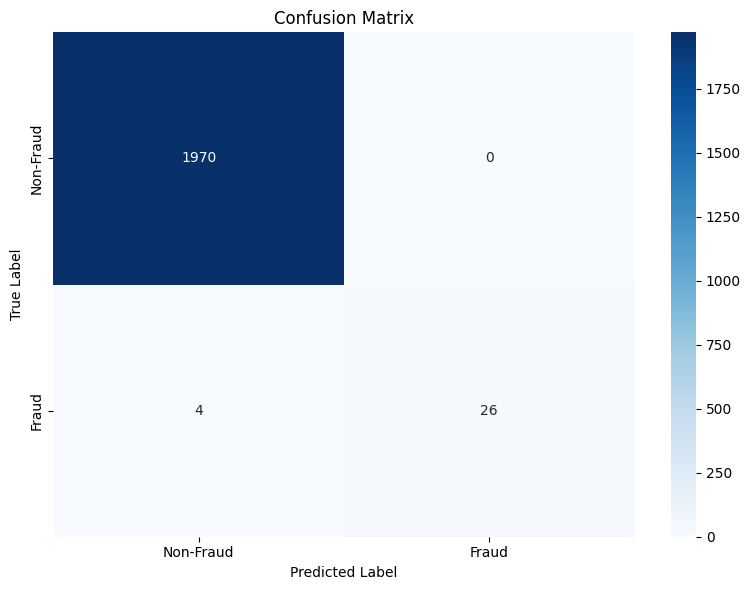

In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 12. Feature Importance

Feature Importance:
               Feature  Importance
6   device_trust_score    0.208140
2     transaction_hour    0.175636
4  foreign_transaction    0.139880
7    velocity_last_24h    0.130724
5    location_mismatch    0.129645
1               amount    0.088993
0       transaction_id    0.056670
8       cardholder_age    0.047624
3    merchant_category    0.022689


C:\Users\User\AppData\Local\Temp\ipykernel_22816\3602136227.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


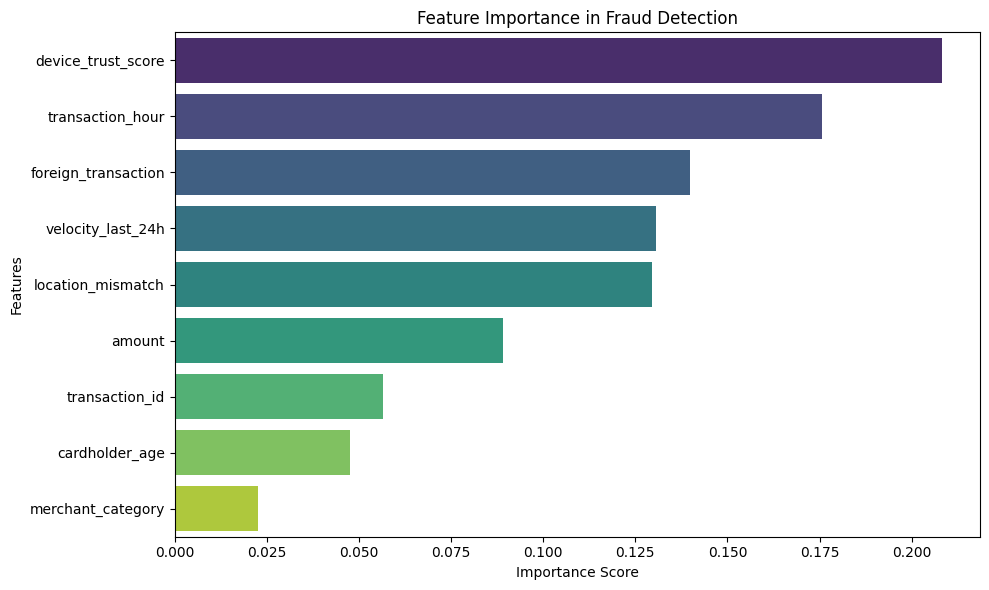

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Fraud Detection')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 13. Summary and Insights

### Key Findings:
- **Data Overview**: The dataset contains transaction-level features for fraud detection
- **Model Performance**: Random Forest classifier with multiple evaluation metrics
- **Feature Importance**: Identifies the most influential features for predicting fraud
- **Next Steps**: Consider hyperparameter tuning, ensemble methods, and class balancing techniques